In [49]:
import os
import itertools
import numpy as np
import math
import matplotlib.pyplot as plt
import time


# Chọn bản đồ + hàm trực quan bản đồ

In [50]:
# ===== Nạp bản đồ =====
# Ưu tiên dùng file local của bạn, sau đó fallback sang file cùng thư mục notebook hoặc /mnt/data.
grid30 = np.loadtxt('E:\last_dance\Last-dance\map\square400.txt', dtype=np.int8)

# ===== Khai báo waypoint bắt buộc =====
# Các ô trong danh sách goals sẽ được đánh dấu bằng giá trị 2 trên grid.
#goals = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15)]
# goals = [(4, 6), (12, 14), (18, 10)]
#goals = [(46, 46), (6, 18), (23, 37), (6, 48), (24, 6), (34, 20), (28, 46), (16, 13), (38, 44), (45, 34)]


# for goal in goals:
#     grid30[goal] = 2

grid = grid30
n = grid.shape[0]

In [51]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_path(grid, path, mandatory_waypoints):
    if path:
        print("\nĐường đi được trích xuất:")
        print(path)
        L_q = path_length(path)
        print("Độ dài đường đi:", round(L_q, 3))

        # Trực quan hóa đường đi Q-Learning
        print("\nĐang trực quan hóa đường đi Q-Learning...")
        fig, ax = plt.subplots(figsize=(8, 8))

        # Vẽ bản đồ (0=free, 1=obstacle)
        # Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
        im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

        # Vẽ đường đi theo từng bước
        xs = [p[1] for p in path] # Hoán đổi x và y để vẽ
        ys = [p[0] for p in path] # Hoán đổi x và y để vẽ
        ax.plot(xs, ys, linewidth=2, color="red", zorder=3) # Sử dụng màu khác cho đường đi Q
        ax.scatter([path[0][1], path[-1][1]], # Hoán đổi x và y để vẽ
                [path[0][0], path[-1][0]], # Hoán đổi x và y để vẽ
                marker='x', s=160, linewidths=2.5, color="red", zorder=4)

        # Vẽ các điểm bắt buộc
        mandatory_wp_x = [wp[1] for wp in mandatory_waypoints]
        mandatory_wp_y = [wp[0] for wp in mandatory_waypoints]
        ax.scatter(mandatory_wp_x, mandatory_wp_y, marker='o', s=100, linewidths=2.5, color="blue", zorder=5, label="Điểm bắt buộc")

        # ======= THÊM LƯỚI Ô NGUYÊN  =======
        n, m = grid.shape
        ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
        ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')

        ax.set_title(f"Đường đi có độ dài={L_q:.2f}, số bước={len(path)-1}")
        ax.legend()

        plt.tight_layout()
        # out_path_q = "/mnt/data/q_learning_path.png"
        # plt.savefig(out_path_q, dpi=180)
        plt.show() # Hiển thị biểu đồ đường đi Q-Learning
        # plt.close(fig)
        # print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

    else:
        print("\nKhông thể trích xuất đường đi hợp lệ từ bảng Q.")

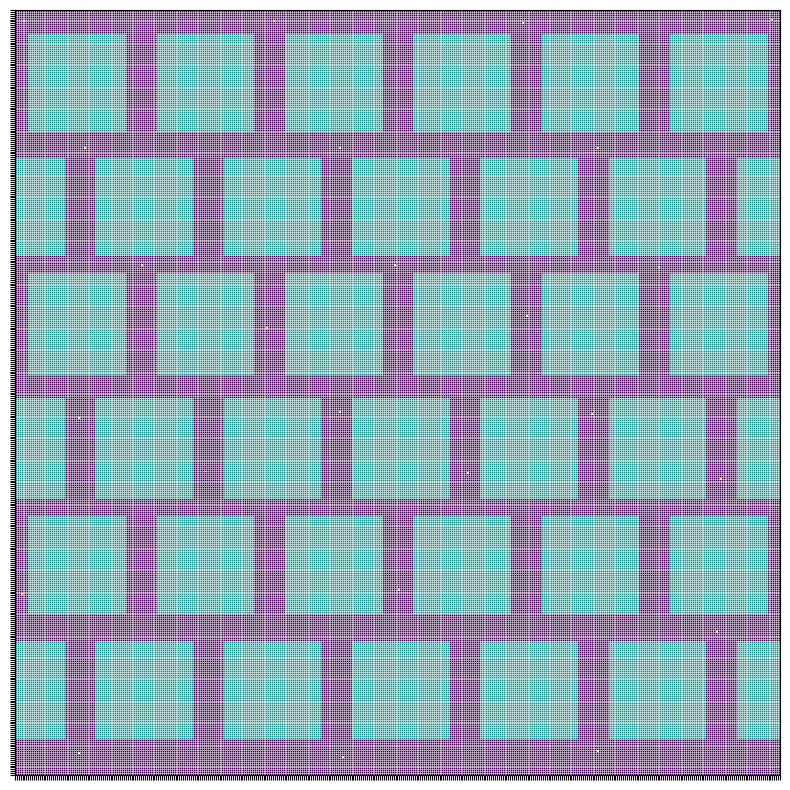

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Trực quan hóa đường đi Q-Learning
fig, ax = plt.subplots(figsize=(8, 8))

# Vẽ bản đồ (0=free, 1=obstacle)
# Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

# ======= THÊM LƯỚI Ô NGUYÊN  =======
n, m = grid.shape
ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
ax.set_aspect('equal')
ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')


plt.tight_layout()
# out_path_q = "/mnt/data/q_learning_path.png"
# plt.savefig(out_path_q, dpi=180)
plt.show() # Hiển thị biểu đồ đường đi Q-Learning
# plt.close(fig)
# print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

So pixel GVD: 5130
Voronoi nodes: [[  1  66]
 [  1 133]
 [  1 199]
 [  1 267]
 [  1 333]
 [ 68  66]
 [ 68 132]
 [ 68 199]
 [ 68 266]
 [ 68 334]
 [ 73  34]
 [ 73 100]
 [ 73 167]
 [ 73 235]
 [ 73 302]
 [ 73 369]
 [129  34]
 [129 101]
 [129 168]
 [129 234]
 [129 301]
 [129 369]
 [137  65]
 [137 132]
 [137 200]
 [137 267]
 [137 333]
 [193  66]
 [193 132]
 [193 200]
 [193 266]
 [193 333]
 [200  34]
 [200 101]
 [200 167]
 [200 235]
 [200 302]
 [200 368]
 [256  33]
 [256 100]
 [256 168]
 [256 234]
 [256 302]
 [256 369]
 [264  66]
 [264 132]
 [264 199]
 [264 266]
 [264 334]
 [320  65]
 [320 132]
 [320 199]
 [320 267]
 [320 333]
 [325  33]
 [325 100]
 [325 168]
 [325 234]
 [325 301]
 [325 368]
 [398  33]
 [398 100]
 [398 167]
 [398 235]
 [398 302]
 [398 368]]


<Axes: title={'center': 'Generalized Voronoi Diagram (medial-axis approximation)'}>

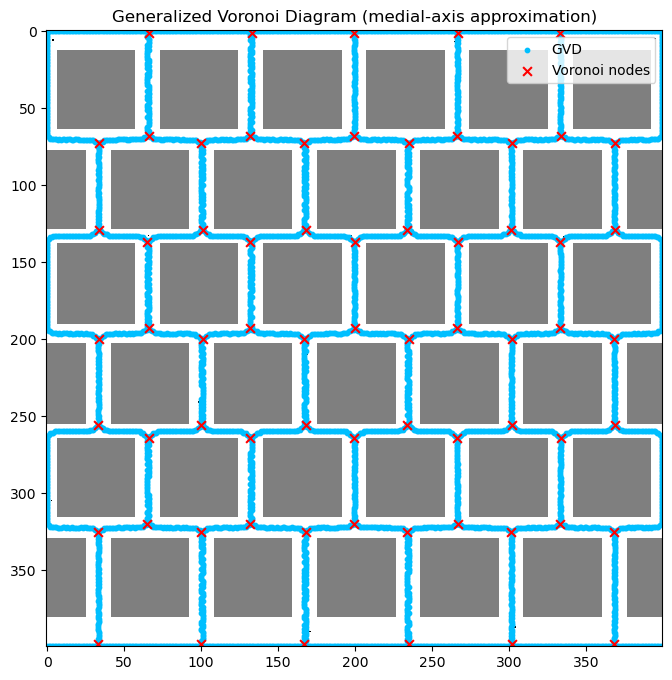

In [53]:
from gvd_helper import build_gvd_from_grid, plot_gvd

gvd = build_gvd_from_grid(grid)   # grid: 0 free, 1 obstacle, 2 goal cũng được
print("So pixel GVD:", len(gvd["gvd_points"]))
print("Voronoi nodes:", gvd["branch_centroids"])

plot_gvd(grid, gvd)

In [54]:
from gvd_ortools_planner import find_shortest_cycle_with_goals_gvd_ortools

# grid: 0 free, 1 obstacle, 2 goal
res = find_shortest_cycle_with_goals_gvd_ortools(
    grid_map=grid,
    goals=None,              # tự lấy toàn bộ ô có giá trị 2
    start_node=None,         # mặc định lấy goal đầu tiên
    max_connections=8,
    distance_scale=1000,
    time_limit_sec=3,
    verbose=True,
)

print("Best order:", res["best_order"])
print("Total length:", res["total_length"])
print("Scaled objective:", res["scaled_objective"])
path = res["full_path"]

GVD-Dijkstra((5, 395) -> (6, 4)) = 391.001
GVD-Dijkstra((5, 395) -> (6, 135)) = 260.002
GVD-Dijkstra((5, 395) -> (7, 265)) = 130.015
GVD-Dijkstra((5, 395) -> (72, 36)) = 447.116
GVD-Dijkstra((5, 395) -> (72, 169)) = 313.044
GVD-Dijkstra((5, 395) -> (72, 304)) = 171.660
GVD-Dijkstra((5, 395) -> (133, 66)) = 488.793
GVD-Dijkstra((5, 395) -> (133, 198)) = 350.663
GVD-Dijkstra((5, 395) -> (134, 336)) = 199.542
GVD-Dijkstra((5, 395) -> (160, 267)) = 303.527
GVD-Dijkstra((5, 395) -> (166, 131)) = 453.748
GVD-Dijkstra((5, 395) -> (210, 169)) = 464.368
GVD-Dijkstra((5, 395) -> (211, 301)) = 323.054
GVD-Dijkstra((5, 395) -> (213, 33)) = 607.660
GVD-Dijkstra((5, 395) -> (241, 99)) = 572.966
GVD-Dijkstra((5, 395) -> (242, 236)) = 431.816
GVD-Dijkstra((5, 395) -> (245, 368)) = 343.300
GVD-Dijkstra((5, 395) -> (303, 200)) = 533.978
GVD-Dijkstra((5, 395) -> (305, 3)) = 741.132
GVD-Dijkstra((5, 395) -> (325, 366)) = 486.558
GVD-Dijkstra((5, 395) -> (387, 304)) = 574.799
GVD-Dijkstra((5, 395) -> (388,

In [ ]:
visualize_path(grid, res["path_nodes"], goals)

# Các hàm phụ trợ

In [55]:
# Kiểm tra điểm có nằm trong lưới không
def in_bounds(p, n, m):
    return 0 <= p[0] < n and 0 <= p[1] < m

# ---------- helpers ----------
MOVES8 = [(-1,-1), (-1,0), (-1,1),
          ( 0,-1),          ( 0,1),
          ( 1,-1), ( 1,0),  ( 1,1)]

# Hàm khoảng cách Euclid giữa hai điểm
def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

# Tính độ dài đường đi
def path_length(path):
    if not path or len(path) < 2:
        return 0.0
    return sum(euclid(path[i], path[i + 1]) for i in range(len(path) - 1))

In [56]:
FOUR_NEIGHBORS = [(-1,0), (1,0), (0,-1), (0,1)]
EIGHT_NEIGHBORS = [(-1,-1), (-1,0), (-1,1),
                   ( 0,-1),          ( 0,1),
                   ( 1,-1), ( 1,0),  ( 1,1)]

def is_free_cell(grid_map, cell, obstacle_value=1):
    n_rows, n_cols = grid_map.shape
    r, c = cell
    return 0 <= r < n_rows and 0 <= c < n_cols and grid_map[r][c] != obstacle_value


def has_clearance(grid_map, cell, obstacle_value=1, clearance_mode=0):
    """
    clearance_mode:
        0 : không xét vùng đệm
        4 : xét 4 ô xung quanh
        8 : xét 8 ô xung quanh
    """
    if not is_free_cell(grid_map, cell, obstacle_value):
        return False

    if clearance_mode == 0:
        return True

    dirs = FOUR_NEIGHBORS if clearance_mode == 4 else EIGHT_NEIGHBORS
    r, c = cell
    n_rows, n_cols = grid_map.shape

    for dr, dc in dirs:
        rr, cc = r + dr, c + dc
        if 0 <= rr < n_rows and 0 <= cc < n_cols:
            if grid_map[rr][cc] == obstacle_value:
                return False
    return True


def can_move_8dir_strict(grid_map, current_node, neighbor_node, obstacle_value=1, clearance_mode=0):
    """
    Kiểm tra một bước đi current_node -> neighbor_node có hợp lệ hay không:
    - neighbor phải free
    - nếu đi chéo thì không được cắt góc tường
    - có thể thêm clearance 4 hoặc 8 ô xung quanh
    """
    if not has_clearance(grid_map, neighbor_node, obstacle_value, clearance_mode):
        return False

    r0, c0 = current_node
    r1, c1 = neighbor_node
    dr = r1 - r0
    dc = c1 - c0

    # chỉ cho bước 8 hướng đúng 1 ô
    if abs(dr) > 1 or abs(dc) > 1 or (dr == 0 and dc == 0):
        return False

    # nếu đi chéo thì cấm xuyên góc
    if abs(dr) == 1 and abs(dc) == 1:
        side1 = (r0 + dr, c0)   # ô đứng theo hàng
        side2 = (r0, c0 + dc)   # ô đứng theo cột

        # 2 ô cạnh phải free
        if not is_free_cell(grid_map, side1, obstacle_value):
            return False
        if not is_free_cell(grid_map, side2, obstacle_value):
            return False

        # nếu muốn khắt khe hơn, cả 2 ô cạnh cũng phải có clearance
        if clearance_mode != 0:
            if not has_clearance(grid_map, side1, obstacle_value, clearance_mode):
                return False
            if not has_clearance(grid_map, side2, obstacle_value, clearance_mode):
                return False

    return True

In [57]:
# Tạo sub_grid từ start_point đến end_point
def create_sub_grid(start_point, end_point, grid):
    x_min = min(start_point[0], end_point[0])
    x_max = max(start_point[0], end_point[0])
    y_min = min(start_point[1], end_point[1])
    y_max = max(start_point[1], end_point[1])
    
    return grid[x_min:x_max+1, y_min:y_max+1]

In [58]:
# Tạo sub_grid từ start_point đến end_point bổ sung padding 1 ô xung quanh để tránh lỗi index khi đi chéo
#def create_sub_grid_with_padding(start_point, end_point, grid, padding):
#    x_min = min(start_point[0], end_point[0])
#    x_max = max(start_point[0], end_point[0])
#    y_min = min(start_point[1], end_point[1])
#    y_max = max(start_point[1], end_point[1])
#    
#    return grid[x_min-padding:x_max+1+padding, y_min-padding:y_max+1+padding]

def create_sub_grid_with_padding(start_point, end_point, grid, padding):
    n_rows, n_cols = grid.shape
    x0 = max(0, min(start_point[0], end_point[0]) - padding)
    x1 = min(n_rows - 1, max(start_point[0], end_point[0]) + padding)
    y0 = max(0, min(start_point[1], end_point[1]) - padding)
    y1 = min(n_cols - 1, max(start_point[1], end_point[1]) + padding)
    return grid[x0:x1+1, y0:y1+1], x0, y0

In [59]:
#test create_sub_grid
start_point = (4, 6)
end_point = (12, 14)
sub_grid = create_sub_grid(start_point, end_point, grid)
print("Sub-grid:")
print(sub_grid)

Sub-grid:
[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


In [60]:
#test create_sub_grid_with_padding
start_point = (4, 6)
end_point = (12, 14)
padding = 1
sub_grid = create_sub_grid_with_padding(start_point, end_point, grid, padding)
print("Sub-grid với padding:")
print(sub_grid)

Sub-grid với padding:
(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int8), 3, 5)


# Dijkstra + vét cạn toàn bộ thứ tự waypoint


In [61]:
# Tìm đường đi ngắn nhất từ start_point đến end_point chỉ đi xuống và sang phải (có thể đi chéo phải)
def find_path_segment_down_right(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][0] = 0

    for i in range(1, n):
        if sub_grid[i][0] != 1:
            d[i][0] = min(d[i][0], d[i-1][0] + 1)

    for j in range(1, m):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j-1] + 1)

    for i in range(1, n):
        for j in range(1, m):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j-1] + 1,          # đi sang phải
                    d[i-1][j-1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][m-1])

    # B2: truy vết đường đi từ (n-1, m-1) về (0,0)
    path = []
    i, j = n-1, m-1

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
        return [], 1e10
    else:
        while not (i == 0 and j == 0):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, trái (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, -1, math.sqrt(2)), (-1, 0, 1), (0, -1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj < 0:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, 0))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]

        return path, d[n-1][m-1]

In [62]:
def find_path_segment_down_left(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][m-1] = 0

    for i in range(1, n):
        if sub_grid[i][m-1] != 1:
            d[i][m-1] = min(d[i][m-1], d[i-1][m-1] + 1)

    for j in range(m-2, -1, -1):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j+1] + 1)

    for i in range(1, n):
        for j in range(m-2, -1, -1):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j+1] + 1,          # đi sang trái
                    d[i-1][j+1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][0])

    # B2: truy vết đường đi từ (n-1, 0) về (0,m-1)
    path = []
    i, j = n-1, 0

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
        return [], 1e10
    else:
        while not (i == 0 and j == m-1):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, phải (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, 1, math.sqrt(2)), (-1, 0, 1), (0, 1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj >= m:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, m-1))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]
        return path, d[n-1][0]

In [63]:
import heapq

# Hàm tìm đường đi ngắn nhất giữa hai điểm (start_point) và (end_point) sử dụng Dijkstra
# Với khả năng di chuyển 8 hướng và tránh chướng ngại vật (giá trị 1)
# Độ phức tạp: O(n*m*log(n*m)) trong trường hợp xấu nhất, với n và m là số hàng và số cột của lưới
def dijkstra(grid_map, start_point, end_point):
    n_rows, n_cols = grid_map.shape

    # Kiểm tra điểm bắt đầu và kết thúc có hợp lệ không
    if not in_bounds(start_point, n_rows, n_cols) or grid_map[start_point[0]][start_point[1]] == 1:
        print(f"Điểm bắt đầu {start_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10 # Trả về đường đi rỗng và độ dài vô cùng lớn nếu điểm bắt đầu không hợp lệ
    if not in_bounds(end_point, n_rows, n_cols) or grid_map[end_point[0]][end_point[1]] == 1:
        print(f"Điểm kết thúc {end_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10

    # distances lưu trữ khoảng cách ngắn nhất từ start_point đến mỗi ô
    # dictionary (row, col) -> min distance giữa start_point và (row, col), kích thước n_rows x n_cols
    distances = { (r, c): 1e10 for r in range(n_rows) for c in range(n_cols) } 
    distances[start_point] = 0

    # predecessors lưu trữ ô trước đó trong đường đi ngắn nhất, dạng dictionary (row, col) -> (prev_row, prev_col)
    predecessors = {}

    # priority_queue (min-heap) để lưu trữ (khoảng_cách, ô_hiện_tại), trong đó khoảng cách là khoảng cách ngắn nhất đã biết từ start_point đến ô_hiện_tại
    priority_queue = [ (0, start_point) ]

    while priority_queue: # Trong khi hàng đợi ưu tiên không rỗng
        current_distance, current_node = heapq.heappop(priority_queue) # Lấy ô có khoảng cách nhỏ nhất từ hàng đợi
        # print(f"Đang xử lý node {current_node} với khoảng cách {current_distance}")
        # print(f"Hàng đợi ưu tiên: {priority_queue}")

        # Nếu đã tìm thấy đường đi ngắn nhất đến current_node rồi, bỏ qua
        if current_distance > distances[current_node]:
            continue

        # Nếu đã đến đích, dừng tìm kiếm
        if current_node == end_point:
            break

        # Duyệt qua 8 ô lân cận
        for dr, dc in MOVES8:
            neighbor_node = (current_node[0] + dr, current_node[1] + dc)

            # Kiểm tra ô lân cận có hợp lệ không (trong biên, không phải chướng ngại vật)
            if in_bounds(neighbor_node, n_rows, n_cols) and grid_map[neighbor_node[0]][neighbor_node[1]] != 1:
                # Tính chi phí di chuyển (1 cho ngang/dọc, sqrt(2) cho chéo)
                move_cost = math.hypot(dr, dc) # math.hypot((dr, dc)) will be 1 or sqrt(2)

                # Tính khoảng cách mới đến ô lân cận
                new_distance = current_distance + move_cost

                # Nếu tìm thấy đường đi ngắn hơn đến ô lân cận
                if new_distance < distances[neighbor_node]:
                    distances[neighbor_node] = new_distance
                    # print(distances)
                    predecessors[neighbor_node] = current_node
                    # print(predecessors)
                    heapq.heappush(priority_queue, (new_distance, neighbor_node))
        
        # for dr, dc in MOVES8:
        #     neighbor_node = (current_node[0] + dr, current_node[1] + dc)

        #     # clearance_mode:
        #     #   0 = chỉ chống đi vào vật cản
        #     #   4 = xét 4 ô xung quanh
        #     #   8 = xét 8 ô xung quanh
        #     if can_move_8dir_strict(
        #         grid_map,
        #         current_node,
        #         neighbor_node,
        #         obstacle_value=1,
        #         clearance_mode=8   # đổi thành 4 nếu bạn chỉ muốn xét 4 ô
        #     ):
        #         move_cost = math.hypot(dr, dc)
        #         new_distance = current_distance + move_cost

        #         if new_distance < distances[neighbor_node]:
        #             distances[neighbor_node] = new_distance
        #             predecessors[neighbor_node] = current_node
        #             heapq.heappush(priority_queue, (new_distance, neighbor_node))

    # Tái tạo đường đi từ end_point về start_point
    path = []
    if distances[end_point] == 1e10: # Không tìm thấy đường đi
        return [], 1e10

    current = end_point
    while current != start_point:
        path.append(current)
        current = predecessors.get(current)
        if current is None: # Lỗi: không thể truy vết về điểm bắt đầu
            return [], 1e10
    path.append(start_point)
    path.reverse()

    return path, distances[end_point]

In [64]:
# def find_path_segment_with_dijkstra(start_point, end_point, grid, padding):
#     sub_grid = create_sub_grid_with_padding(start_point, end_point, grid, padding)
#     # down, right
#     if start_point[0] <= end_point[0] and start_point[1] <= end_point[1]:
#         path, dist = dijkstra(sub_grid, (padding, padding), (sub_grid.shape[0]-1-padding, sub_grid.shape[1]-1-padding))
#     elif start_point[0] <= end_point[0] and start_point[1] > end_point[1]: # down, left
#         path, dist = dijkstra(sub_grid, (padding, sub_grid.shape[1]-1-padding), (sub_grid.shape[0]-1-padding, padding))
#     elif start_point[0] > end_point[0] and start_point[1] <= end_point[1]: # up, right
#         path, dist = dijkstra(sub_grid, (sub_grid.shape[0]-1-padding, padding), (padding, sub_grid.shape[1]-1-padding))
#     else: # up, left
#         path, dist = dijkstra(sub_grid, (sub_grid.shape[0]-1-padding, sub_grid.shape[1]-1-padding), (padding, padding))
    
#     # Cộng thêm offset để chuyển từ sub_grid về grid gốc
#     offset_x = min(start_point[0], end_point[0]) - padding
#     offset_y = min(start_point[1], end_point[1]) - padding
#     path = [(x + offset_x, y + offset_y) for x, y in path]
    
#     return path, dist

In [65]:
def find_path_segment_with_dijkstra(start_point, end_point, grid, padding):
    sub_grid, x0, y0 = create_sub_grid_with_padding(start_point, end_point, grid, padding)
    local_start = (start_point[0] - x0, start_point[1] - y0)
    local_end = (end_point[0] - x0, end_point[1] - y0)
    path, dist = dijkstra(sub_grid, local_start, local_end)
    path = [(r + x0, c + y0) for r, c in path]
    return path, dist

In [66]:
# test find_path_segment_with_dijkstra
start_point = (4, 6)
end_point = (4, 15)
padding = 1
path, dist = find_path_segment_with_dijkstra(start_point, end_point, grid, padding)
print("Đường đi tìm được bởi Dijkstra:")
print(path)
print("Độ dài đường đi:", dist)

Đường đi tìm được bởi Dijkstra:
[(4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (4, 14), (4, 15)]
Độ dài đường đi: 9.0


In [67]:

import subprocess
import sys

try:
    from ortools.constraint_solver import pywrapcp, routing_enums_pb2
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ortools"])
    from ortools.constraint_solver import pywrapcp, routing_enums_pb2

INF = 1e10
DISTANCE_SCALE_DEFAULT = 1000
BIG_M_DEFAULT = 10**12


def reverse_path(path):
    return list(reversed(path)) if path else []


def merge_segments(segments):
    total_path = []
    for i, segment in enumerate(segments):
        if not segment:
            return []
        if i == 0:
            total_path.extend(segment)
        else:
            total_path.extend(segment[1:])
    return total_path


def build_pairwise_shortest_paths(grid_map, points, verbose=True):
    """
    Tính trước đường đi ngắn nhất giữa mọi cặp điểm trong danh sách points.
    Vì chi phí di chuyển đối xứng, chỉ cần chạy Dijkstra cho mỗi cặp 1 lần.
    """
    start_time = time.time()
    pairwise_cache = {}

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            a = points[i]
            b = points[j]

            path_ab, dist_ab = find_path_segment_with_dijkstra(a, b, grid_map, padding=0)
            pad = 1
            while dist_ab > 1e9 and pad <= 200:
                path_ab, dist_ab = find_path_segment_with_dijkstra(a, b, grid_map, padding=pad)
                pad += 1

            pairwise_cache[(a, b)] = (path_ab, dist_ab)

            if path_ab:
                pairwise_cache[(b, a)] = (reverse_path(path_ab), dist_ab)
            else:
                pairwise_cache[(b, a)] = ([], INF)

            if verbose:
                if dist_ab >= INF:
                    print(f'Không có đường đi giữa {a} và {b}')
                else:
                    print(f'Dijkstra({a} -> {b}) = {dist_ab:.3f}')

    print("--- %s seconds ---" % (time.time() - start_time))
    return pairwise_cache


def build_cost_matrix(points, pairwise_cache):
    n_points = len(points)
    matrix = [[INF for _ in range(n_points)] for _ in range(n_points)]
    for i, a in enumerate(points):
        for j, b in enumerate(points):
            if i == j:
                matrix[i][j] = 0.0
            else:
                d = pairwise_cache[(a, b)][1]
                matrix[i][j] = d if d < INF else INF
    return matrix


def build_integer_cost_matrix(points, pairwise_cache, distance_scale=DISTANCE_SCALE_DEFAULT, big_m=BIG_M_DEFAULT):
    """
    OR-Tools Routing Solver yêu cầu chi phí cạnh là số nguyên.
    Với robot đi 8 hướng, ta scale chi phí thực (có thể chứa sqrt(2))
    lên số nguyên, ví dụ:
        1.0      -> 1000
        sqrt(2)  -> 1414
    """
    float_matrix = build_cost_matrix(points, pairwise_cache)
    int_matrix = []

    for row in float_matrix:
        int_row = []
        for d in row:
            if d >= INF:
                int_row.append(big_m)
            else:
                int_row.append(int(round(d * distance_scale)))
        int_matrix.append(int_row)

    return int_matrix


def solve_cycle_tsp_with_ortools(
    int_cost_matrix,
    start_idx=0,
    time_limit_sec=10,
    first_solution_strategy=routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC,
    local_search_metaheuristic=routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH,
):
    n_points = len(int_cost_matrix)
    manager = pywrapcp.RoutingIndexManager(n_points, 1, start_idx)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int_cost_matrix[from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = first_solution_strategy
    search_parameters.local_search_metaheuristic = local_search_metaheuristic
    search_parameters.time_limit.seconds = time_limit_sec

    solution = routing.SolveWithParameters(search_parameters)
    if solution is None:
        return None, None

    index = routing.Start(0)
    visit_order = []
    scaled_cost = 0

    while not routing.IsEnd(index):
        visit_order.append(manager.IndexToNode(index))
        next_index = solution.Value(routing.NextVar(index))
        scaled_cost += routing.GetArcCostForVehicle(index, next_index, 0)
        index = next_index

    return visit_order, scaled_cost


def solve_path_tsp_with_ortools(
    int_cost_matrix,
    start_idx,
    end_idx,
    time_limit_sec=10,
    first_solution_strategy=routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC,
    local_search_metaheuristic=routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH,
):
    n_points = len(int_cost_matrix)
    manager = pywrapcp.RoutingIndexManager(n_points, 1, [start_idx], [end_idx])
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int_cost_matrix[from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = first_solution_strategy
    search_parameters.local_search_metaheuristic = local_search_metaheuristic
    search_parameters.time_limit.seconds = time_limit_sec

    solution = routing.SolveWithParameters(search_parameters)
    if solution is None:
        return None, None

    index = routing.Start(0)
    visit_order = []
    scaled_cost = 0

    while True:
        visit_order.append(manager.IndexToNode(index))
        if routing.IsEnd(index):
            break
        next_index = solution.Value(routing.NextVar(index))
        scaled_cost += routing.GetArcCostForVehicle(index, next_index, 0)
        index = next_index

    return visit_order, scaled_cost


def reconstruct_route_from_order(order_points, pairwise_cache, close_cycle=False):
    if not order_points:
        return [], INF

    route_points = order_points[:]
    if close_cycle and len(route_points) >= 1:
        route_points = route_points + [route_points[0]]

    segments = []
    total_length = 0.0

    for a, b in zip(route_points[:-1], route_points[1:]):
        seg_path, seg_cost = pairwise_cache[(a, b)]
        if seg_cost >= INF or not seg_path:
            return [], INF
        segments.append(seg_path)
        total_length += seg_cost

    return merge_segments(segments), total_length


def find_shortest_path_with_mandatory_waypoints_ortools(
    grid_map,
    start_node,
    end_node,
    mandatory_waypoints,
    distance_scale=DISTANCE_SCALE_DEFAULT,
    time_limit_sec=10,
    verbose=True,
):
    """
    Dùng OR-Tools Routing Solver để tìm thứ tự đi qua các waypoint bắt buộc.
    Lưu ý:
    - OR-Tools yêu cầu ma trận chi phí nguyên.
    - Ta chỉ scale chi phí để solver tối ưu thứ tự.
    - Độ dài đường đi cuối cùng vẫn được tính bằng chi phí thực từ Dijkstra.
    """
    mandatory_waypoints = list(dict.fromkeys(mandatory_waypoints))

    # Trường hợp bài toán là chu trình: start == end
    if start_node == end_node:
        cycle_points = [start_node] + [wp for wp in mandatory_waypoints if wp != start_node]
        cycle_points = list(dict.fromkeys(cycle_points))

        if len(cycle_points) == 1:
            return ([start_node], 0.0), [], {}, {
                "solver": "OR-Tools",
                "distance_scale": distance_scale,
                "time_limit_sec": time_limit_sec,
                "scaled_objective": 0,
            }

        pairwise_cache = build_pairwise_shortest_paths(grid_map, cycle_points, verbose=verbose)
        int_cost_matrix = build_integer_cost_matrix(
            cycle_points, pairwise_cache, distance_scale=distance_scale
        )

        best_idx_order, scaled_objective = solve_cycle_tsp_with_ortools(
            int_cost_matrix=int_cost_matrix,
            start_idx=0,
            time_limit_sec=time_limit_sec,
        )

        if not best_idx_order:
            return ([], INF), [], pairwise_cache, {
                "solver": "OR-Tools",
                "distance_scale": distance_scale,
                "time_limit_sec": time_limit_sec,
                "scaled_objective": None,
            }

        ordered_cycle_points = [cycle_points[i] for i in best_idx_order]

        if ordered_cycle_points[0] != start_node:
            return ([], INF), [], pairwise_cache, {
                "solver": "OR-Tools",
                "distance_scale": distance_scale,
                "time_limit_sec": time_limit_sec,
                "scaled_objective": scaled_objective,
            }

        best_order = ordered_cycle_points[1:]
        best_path, best_length = reconstruct_route_from_order(
            [start_node] + best_order, pairwise_cache, close_cycle=True
        )

        return (best_path, best_length), best_order, pairwise_cache, {
            "solver": "OR-Tools",
            "distance_scale": distance_scale,
            "time_limit_sec": time_limit_sec,
            "scaled_objective": scaled_objective,
        }

    # Trường hợp tổng quát: start != end
    inner_waypoints = [wp for wp in mandatory_waypoints if wp != start_node and wp != end_node]
    inner_waypoints = list(dict.fromkeys(inner_waypoints))

    if not inner_waypoints:
        path, dist = dijkstra(grid_map, start_node, end_node)
        return (path, dist), [], {}, {
            "solver": "OR-Tools",
            "distance_scale": distance_scale,
            "time_limit_sec": time_limit_sec,
            "scaled_objective": int(round(dist * distance_scale)) if dist < INF else None,
        }

    points = [start_node] + inner_waypoints + [end_node]
    start_idx = 0
    end_idx = len(points) - 1

    pairwise_cache = build_pairwise_shortest_paths(grid_map, points, verbose=verbose)
    int_cost_matrix = build_integer_cost_matrix(
        points, pairwise_cache, distance_scale=distance_scale
    )

    best_idx_order, scaled_objective = solve_path_tsp_with_ortools(
        int_cost_matrix=int_cost_matrix,
        start_idx=start_idx,
        end_idx=end_idx,
        time_limit_sec=time_limit_sec,
    )

    if not best_idx_order:
        return ([], INF), [], pairwise_cache, {
            "solver": "OR-Tools",
            "distance_scale": distance_scale,
            "time_limit_sec": time_limit_sec,
            "scaled_objective": None,
        }

    ordered_points = [points[i] for i in best_idx_order]

    if ordered_points[0] != start_node or ordered_points[-1] != end_node:
        return ([], INF), [], pairwise_cache, {
            "solver": "OR-Tools",
            "distance_scale": distance_scale,
            "time_limit_sec": time_limit_sec,
            "scaled_objective": scaled_objective,
        }

    best_order = ordered_points[1:-1]
    best_path, best_length = reconstruct_route_from_order(
        [start_node] + best_order + [end_node], pairwise_cache, close_cycle=False
    )

    return (best_path, best_length), best_order, pairwise_cache, {
        "solver": "OR-Tools",
        "distance_scale": distance_scale,
        "time_limit_sec": time_limit_sec,
        "scaled_objective": scaled_objective,
    }


In [68]:

# --- Thực thi chính với OR-Tools cho pha 2 TSP ---
start_exec_time = time.time()

# Trích xuất các waypoint bắt buộc (giá trị 2) từ bản đồ
mandatory_waypoints = []
for r in range(n):
    for c in range(grid.shape[1]):
        if grid[r][c] == 2:
            mandatory_waypoints.append((r, c))

if not mandatory_waypoints:
    raise ValueError("Grid hiện tại không có waypoint nào mang giá trị 2.")

it = 0
grid[mandatory_waypoints[it][0]][mandatory_waypoints[it][1]] = 0
start_node = (mandatory_waypoints[it][0], mandatory_waypoints[it][1])
end_node = (mandatory_waypoints[it][0], mandatory_waypoints[it][1])

mandatory_waypoints = list(dict.fromkeys(mandatory_waypoints))

print(f'Start node: {start_node}')
print(f'End node: {end_node}')
print(f'Các waypoint bắt buộc: {mandatory_waypoints}')
print(f'Số waypoint bắt buộc: {len(mandatory_waypoints)}')

if start_node == end_node:
    print("Bài toán hiện tại đang được giải dưới dạng chu trình (cycle TSP).")

# OR-Tools yêu cầu ma trận chi phí nguyên.
# Vì robot đi 8 hướng nên chi phí có thể chứa sqrt(2), ta scale lên trước rồi làm tròn.
distance_scale = 1000

(path, L_q), best_order, pairwise_cache, ortools_info = find_shortest_path_with_mandatory_waypoints_ortools(
    grid_map=grid,
    start_node=start_node,
    end_node=end_node,
    mandatory_waypoints=mandatory_waypoints,
    distance_scale=distance_scale,
    time_limit_sec=3,
    verbose=True,
)

end_exec_time = time.time()

print()
print('===== KẾT QUẢ =====')
print(f"Bộ giải sử dụng: {ortools_info.get('solver', 'OR-Tools')}")

if L_q >= INF:
    print('Không tìm thấy đường đi hợp lệ đi qua tất cả waypoint bắt buộc.')
else:
    print(f'Thứ tự waypoint tốt nhất OR-Tools tìm được: {best_order}')
    print(f'Độ dài đường đi tốt nhất (chi phí thực từ Dijkstra): {L_q:.3f}')
    print(f'Giá trị mục tiêu sau khi scale cho OR-Tools: {ortools_info.get("scaled_objective")}')
    print('Đường đi (theo thứ tự các ô):')
    for cell in path:
        print(cell)

print(f'Thời gian chạy: {end_exec_time - start_exec_time:.6f} giây')
print('Gợi ý: tăng time_limit_sec nếu số waypoint nhiều hơn.')
print("Thông tin OR-Tools:", ortools_info)


Start node: (5, 395)
End node: (5, 395)
Các waypoint bắt buộc: [(5, 395), (6, 4), (6, 135), (7, 265), (72, 36), (72, 169), (72, 304), (133, 66), (133, 198), (134, 336), (160, 267), (166, 131), (210, 169), (211, 301), (213, 33), (241, 99), (242, 236), (245, 368), (303, 200), (305, 3), (325, 366), (387, 304), (388, 33), (390, 171)]
Số waypoint bắt buộc: 24
Bài toán hiện tại đang được giải dưới dạng chu trình (cycle TSP).
Dijkstra((5, 395) -> (6, 4)) = 391.414
Dijkstra((5, 395) -> (6, 135)) = 260.414
Dijkstra((5, 395) -> (7, 265)) = 130.828
Dijkstra((5, 395) -> (72, 36)) = 407.255
Dijkstra((5, 395) -> (72, 169)) = 274.255
Dijkstra((5, 395) -> (72, 304)) = 139.255
Dijkstra((5, 395) -> (133, 66)) = 423.024
Dijkstra((5, 395) -> (133, 198)) = 291.024
Dijkstra((5, 395) -> (134, 336)) = 165.740
Dijkstra((5, 395) -> (160, 267)) = 241.995
Dijkstra((5, 395) -> (166, 131)) = 382.823
Dijkstra((5, 395) -> (210, 169)) = 374.179
Dijkstra((5, 395) -> (211, 301)) = 254.309
Dijkstra((5, 395) -> (213, 33))


Đường đi được trích xuất:
[(5, 395), (5, 394), (5, 393), (5, 392), (5, 391), (5, 390), (5, 389), (5, 388), (5, 387), (5, 386), (5, 385), (5, 384), (5, 383), (5, 382), (5, 381), (5, 380), (5, 379), (5, 378), (5, 377), (5, 376), (5, 375), (5, 374), (5, 373), (5, 372), (5, 371), (5, 370), (5, 369), (5, 368), (5, 367), (5, 366), (5, 365), (5, 364), (5, 363), (5, 362), (5, 361), (5, 360), (5, 359), (5, 358), (5, 357), (5, 356), (5, 355), (5, 354), (5, 353), (5, 352), (5, 351), (5, 350), (5, 349), (5, 348), (5, 347), (5, 346), (5, 345), (5, 344), (5, 343), (5, 342), (5, 341), (5, 340), (5, 339), (5, 338), (5, 337), (5, 336), (5, 335), (5, 334), (5, 333), (5, 332), (5, 331), (5, 330), (5, 329), (5, 328), (5, 327), (5, 326), (5, 325), (5, 324), (5, 323), (5, 322), (5, 321), (5, 320), (5, 319), (5, 318), (5, 317), (5, 316), (5, 315), (5, 314), (5, 313), (5, 312), (5, 311), (5, 310), (5, 309), (5, 308), (5, 307), (5, 306), (5, 305), (5, 304), (5, 303), (5, 302), (5, 301), (5, 300), (5, 299), (5

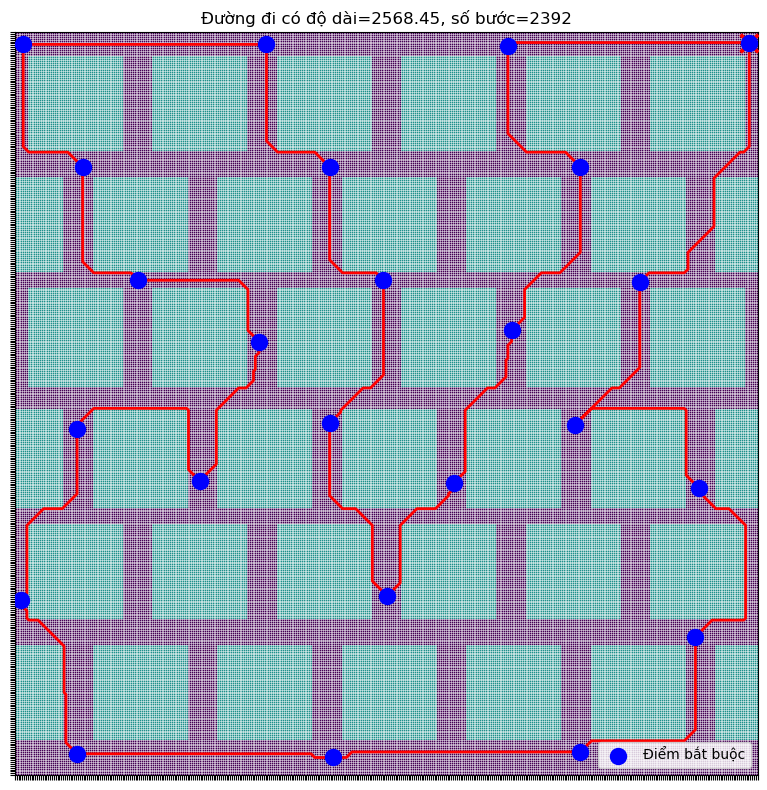

In [69]:
visualize_path(grid, path, mandatory_waypoints)

# Làm mượt đường đi theo đúng Hình 2 của bài báo

Ở Hình 2, phần làm mượt **không ép robot đi lại theo đường gấp khúc cũ**. Ý đúng là:

1. Từ `path` gốc, chỉ giữ lại **start**, **goal**, **các inflection point**, và **mandatory waypoints**.  
2. Xét từng bộ ba điểm liên tiếp `A, B, C` trong danh sách key points.  
3. Nếu có thể **nối thẳng trực tiếp** `A -> C` mà không xuyên qua obstacle thì bỏ `B` (trừ khi `B` là waypoint bắt buộc).  
4. Path sau cùng được hiểu là một **polyline** đi qua các key points còn lại; mỗi đoạn giữa hai key points liên tiếp là **một đoạn thẳng**.

Để kiểm tra điều kiện “không có vật cản nằm giữa đường thẳng”, bên dưới dùng **supercover line-of-sight**.  
Lưu ý: danh sách `smoothed_vertices` là **các đỉnh của polyline sau làm mượt**. Nếu cần một danh sách ô lưới để debug/hiển thị, notebook vẫn tạo thêm `smoothed_path_cells`.


In [70]:
# ===== Hậu xử lý làm mượt đường đi theo đúng Hình 2 của bài báo =====

def remove_consecutive_duplicates(path):
    """
    Xóa các phần tử trùng nhau liên tiếp trong path
    """
    if not path:
        return []
    compact = [path[0]]
    for pt in path[1:]:
        if pt != compact[-1]:
            compact.append(pt)
    return compact


def extract_inflection_points(path, mandatory_waypoints, keep_start_goal=True):
    """
    Bước 2 của bài báo:
    giữ lại start, goal, các inflection point và các mandatory waypoint.
    """
    path = remove_consecutive_duplicates(path)
    if not path:
        return []

    mandatory_set = set(mandatory_waypoints)
    selected = []

    for i, pt in enumerate(path):
        keep = False

        if keep_start_goal and (i == 0 or i == len(path) - 1):
            keep = True

        if pt in mandatory_set:
            keep = True

        if 0 < i < len(path) - 1:
            v1 = (path[i][0] - path[i - 1][0], path[i][1] - path[i - 1][1])
            v2 = (path[i + 1][0] - path[i][0], path[i + 1][1] - path[i][1])

            # đổi hướng => inflection point
            if v1 != v2:
                keep = True

        if keep:
            selected.append(pt)

    return selected


import math

def supercover_line(a, b):
    """
    Trả về tất cả ô mà đoạn thẳng nối tâm ô a -> tâm ô b đi qua hoặc chạm vào.
    Point có dạng (row, col).
    """
    r0, c0 = a
    r1, c1 = b

    x0, y0 = c0 + 0.5, r0 + 0.5
    x1, y1 = c1 + 0.5, r1 + 0.5

    dx = x1 - x0
    dy = y1 - y0

    cells = {(r0, c0), (r1, c1)}

    steps = int(max(abs(dx), abs(dy)) * 20) + 1

    for k in range(steps + 1):
        t = k / steps
        x = x0 + dx * t
        y = y0 + dy * t

        c = int(math.floor(x))
        r = int(math.floor(y))
        cells.add((r, c))

        eps = 1e-9
        fx = x - math.floor(x)
        fy = y - math.floor(y)

        # nếu đoạn đi đúng trên biên ô thì thêm cả ô kề
        if abs(fx) < eps:
            cells.add((r, c - 1))
        if abs(fy) < eps:
            cells.add((r - 1, c))
        if abs(fx) < eps and abs(fy) < eps:
            cells.add((r - 1, c - 1))

    def proj(cell):
        rr, cc = cell
        cx, cy = cc + 0.5, rr + 0.5
        if abs(dx) >= abs(dy):
            return (cx - x0) / (dx if abs(dx) > 1e-12 else 1.0)
        return (cy - y0) / (dy if abs(dy) > 1e-12 else 1.0)

    cells = [p for p in cells if isinstance(p[0], int) and isinstance(p[1], int)]
    return sorted(cells, key=proj)


# def has_line_of_sight_strict(grid_map, a, b, obstacle_value=1):
#     """
#     Đoạn a -> b chỉ hợp lệ nếu không chạm bất kỳ ô obstacle nào.
#     """
#     n_rows, n_cols = grid_map.shape
#     for r, c in supercover_line(a, b):
#         if not (0 <= r < n_rows and 0 <= c < n_cols):
#             return False
#         if grid_map[r][c] == obstacle_value:
#             return False
#     return True

def has_line_of_sight_strict(grid_map, a, b, obstacle_value=1, clearance_mode=8):
    """
    Đoạn a -> b hợp lệ nếu:
    - không đi qua ô obstacle
    - mỗi ô trên đoạn đều đạt clearance
    - nếu giữa 2 ô liên tiếp trên supercover là bước chéo, không được cắt góc tường
    """
    cells = supercover_line(a, b)

    if not cells:
        return False

    for i, cell in enumerate(cells):
        # ô trên đoạn phải an toàn
        if not has_clearance(grid_map, cell, obstacle_value, clearance_mode):
            return False

        # kiểm tra corner-cut giữa 2 ô liên tiếp trên đoạn raster
        if i > 0:
            prev = cells[i - 1]
            r0, c0 = prev
            r1, c1 = cell
            dr = r1 - r0
            dc = c1 - c0

            if abs(dr) == 1 and abs(dc) == 1:
                side1 = (r0 + dr, c0)
                side2 = (r0, c0 + dc)

                if not is_free_cell(grid_map, side1, obstacle_value):
                    return False
                if not is_free_cell(grid_map, side2, obstacle_value):
                    return False

                if clearance_mode != 0:
                    if not has_clearance(grid_map, side1, obstacle_value, clearance_mode):
                        return False
                    if not has_clearance(grid_map, side2, obstacle_value, clearance_mode):
                        return False

    return True


def rasterize_polyline(vertices):
    """
    Chỉ để hiển thị/debug: biến polyline thành danh sách ô mà nó đi qua.
    """
    if not vertices:
        return []

    cells = [vertices[0]]
    for i in range(len(vertices) - 1):
        seg = supercover_line(vertices[i], vertices[i + 1])
        if cells[-1] == seg[0]:
            cells.extend(seg[1:])
        else:
            cells.extend(seg)
    return cells


def count_turns(path_or_vertices):
    pts = remove_consecutive_duplicates(path_or_vertices)
    if len(pts) < 3:
        return 0

    turns = 0
    for i in range(1, len(pts) - 1):
        v1 = (pts[i][0] - pts[i - 1][0], pts[i][1] - pts[i - 1][1])
        v2 = (pts[i + 1][0] - pts[i][0], pts[i + 1][1] - pts[i][1])
        if v1 != v2:
            turns += 1
    return turns


def polyline_length(vertices):
    """
    Độ dài thật của path sau làm mượt:
    tổng độ dài các đoạn thẳng giữa các vertices liên tiếp.
    """
    if not vertices or len(vertices) < 2:
        return 0.0
    return sum(euclid(vertices[i], vertices[i + 1]) for i in range(len(vertices) - 1))


def smooth_key_points_by_paper(grid_map, key_points, mandatory_waypoints):
    """
    Bước 3/4 theo đúng ý Hình 2:
    - làm việc trên danh sách key points
    - xét các bộ ba A, B, C liên tiếp
    - nếu A -> C không va obstacle thì bỏ B
    - không bao giờ bỏ mandatory waypoint
    """
    if len(key_points) <= 2:
        return key_points[:]

    mandatory_set = set(mandatory_waypoints)
    pts = key_points[:]

    i = 0
    while i < len(pts) - 2:
        A = pts[i]
        B = pts[i + 1]
        C = pts[i + 2]

        can_skip_B = (
            B not in mandatory_set
            and has_line_of_sight_strict(grid_map, A, C, obstacle_value=1, clearance_mode=8)
        )

        if can_skip_B:
            del pts[i + 1]
            if i > 0:
                i -= 1
        else:
            i += 1

    return pts


def smooth_path_by_paper(grid_map, raw_path, mandatory_waypoints):
    key_points = extract_inflection_points(raw_path, mandatory_waypoints, keep_start_goal=True)
    if len(key_points) <= 2:
        return key_points, key_points[:], rasterize_polyline(key_points)

    mandatory_set = set(mandatory_waypoints)
    smoothed_vertices = key_points[:]

    i = 0
    while i < len(smoothed_vertices) - 2:
        A = smoothed_vertices[i]
        B = smoothed_vertices[i + 1]
        C = smoothed_vertices[i + 2]

        if B not in mandatory_set and has_line_of_sight_strict(grid_map, A, C):
            del smoothed_vertices[i + 1]
            if i > 0:
                i -= 1
        else:
            i += 1

    smoothed_path_cells = rasterize_polyline(smoothed_vertices)
    return key_points, smoothed_vertices, smoothed_path_cells


def visualize_smoothing_comparison(grid, raw_path, smoothed_vertices, mandatory_waypoints,
                                   key_points_before=None, key_points_after=None):
    """
    Vẽ so sánh giống tinh thần Hình 2:
    - path gốc: nét đứt đen
    - path sau làm mượt: các đoạn thẳng xanh nối trực tiếp giữa key points
    - mandatory waypoints: xanh lá
    - key points sau làm mượt: đỏ
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(grid, origin="upper", interpolation="nearest", cmap="gray_r")

    n, m = grid.shape
    ax.set_xlim(-0.5, m - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.8)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    if raw_path:
        xs = [p[1] for p in raw_path]
        ys = [p[0] for p in raw_path]
        ax.plot(xs, ys, "k--", linewidth=2.5, label="Path gốc")

    if smoothed_vertices:
        xs = [p[1] for p in smoothed_vertices]
        ys = [p[0] for p in smoothed_vertices]
        ax.plot(xs, ys, linewidth=3, color="#18a0e0", label="Path sau làm mượt (đoạn thẳng)")

        ax.scatter(
            [smoothed_vertices[0][1], smoothed_vertices[-1][1]],
            [smoothed_vertices[0][0], smoothed_vertices[-1][0]],
            marker="x", s=160, linewidths=2.5, color="red", zorder=5
        )

    if mandatory_waypoints:
        ax.scatter(
            [p[1] for p in mandatory_waypoints],
            [p[0] for p in mandatory_waypoints],
            marker="o", s=90, linewidths=2, edgecolors="green",
            facecolors="none", zorder=6, label="Mandatory"
        )

    if key_points_after:
        ax.scatter(
            [p[1] for p in key_points_after],
            [p[0] for p in key_points_after],
            marker="s", s=55, color="red", zorder=6, label="Vertices sau rút gọn"
        )

    ax.set_title("So sánh path gốc và polyline sau làm mượt")
    ax.legend(loc="best")
    plt.show()


In [71]:
print(extract_inflection_points(path, mandatory_waypoints, keep_start_goal=True))

[(5, 395), (5, 269), (7, 267), (7, 265), (54, 265), (64, 275), (64, 296), (72, 304), (118, 304), (129, 293), (129, 283), (138, 274), (153, 274), (160, 267), (166, 267), (168, 265), (175, 265), (176, 264), (185, 264), (191, 258), (191, 254), (203, 242), (236, 242), (242, 236), (245, 236), (248, 233), (249, 233), (256, 226), (256, 216), (265, 207), (296, 207), (303, 200), (295, 192), (265, 192), (256, 183), (256, 176), (249, 169), (210, 169), (204, 175), (203, 175), (191, 187), (191, 191), (184, 198), (133, 198), (129, 194), (129, 176), (122, 169), (72, 169), (64, 161), (64, 141), (58, 135), (6, 135), (6, 4), (61, 4), (64, 7), (64, 28), (72, 36), (123, 36), (129, 42), (129, 62), (133, 66), (133, 120), (138, 125), (160, 125), (166, 131), (172, 131), (174, 129), (181, 129), (182, 128), (187, 128), (191, 124), (191, 120), (203, 108), (232, 108), (241, 99), (235, 93), (203, 93), (202, 92), (202, 42), (211, 33), (213, 33), (248, 33), (256, 25), (256, 15), (265, 6), (302, 6), (305, 3), (308, 3

In [72]:
# test supercover_line

a = (0, 0)
b = (2, 3)
cells = supercover_line(a, b)
print("Cells covered by line from", a, "to", b, ":", cells)

Cells covered by line from (0, 0) to (2, 3) : [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (2, 3)]


===== LÀM MƯỢT ĐƯỜNG ĐI =====
Key points trước khi rút gọn (start + inflection + mandatory + goal):
[(5, 395), (5, 269), (7, 267), (7, 265), (54, 265), (64, 275), (64, 296), (72, 304), (118, 304), (129, 293), (129, 283), (138, 274), (153, 274), (160, 267), (166, 267), (168, 265), (175, 265), (176, 264), (185, 264), (191, 258), (191, 254), (203, 242), (236, 242), (242, 236), (245, 236), (248, 233), (249, 233), (256, 226), (256, 216), (265, 207), (296, 207), (303, 200), (295, 192), (265, 192), (256, 183), (256, 176), (249, 169), (210, 169), (204, 175), (203, 175), (191, 187), (191, 191), (184, 198), (133, 198), (129, 194), (129, 176), (122, 169), (72, 169), (64, 161), (64, 141), (58, 135), (6, 135), (6, 4), (61, 4), (64, 7), (64, 28), (72, 36), (123, 36), (129, 42), (129, 62), (133, 66), (133, 120), (138, 125), (160, 125), (166, 131), (172, 131), (174, 129), (181, 129), (182, 128), (187, 128), (191, 124), (191, 120), (203, 108), (232, 108), (241, 99), (235, 93), (203, 93), (202, 92), (20

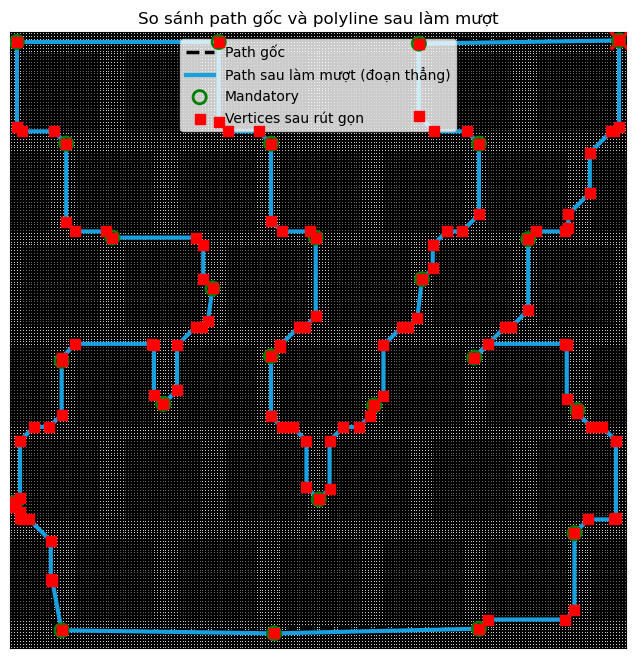

In [73]:
# ===== Chạy bước làm mượt sau khi đã có path từ Dijkstra + OR-Tools =====
if path and L_q < INF:
    key_points_before, smoothed_vertices, smoothed_path_cells = smooth_path_by_paper(
        grid, path, mandatory_waypoints
    )

    L_q_smooth = polyline_length(smoothed_vertices)
    turns_before = count_turns(path)
    turns_after = count_turns(smoothed_vertices)

    print('===== LÀM MƯỢT ĐƯỜNG ĐI =====')
    print('Key points trước khi rút gọn (start + inflection + mandatory + goal):')
    print(key_points_before)
    print()
    print('Vertices sau khi rút gọn (path cuối là các đoạn thẳng nối các điểm này):')
    print(smoothed_vertices)
    print()
    print(f'Độ dài path gốc: {path_length(path):.3f}')
    print(f'Độ dài polyline sau làm mượt: {L_q_smooth:.3f}')
    print(f'Số điểm rẽ trước khi làm mượt: {turns_before}')
    print(f'Số điểm rẽ sau khi làm mượt: {turns_after}')
    print('Danh sách vertices của đường đi sau làm mượt:')
    for pt in smoothed_vertices:
        print(pt)

    print('\nDanh sách ô lưới mà polyline sau làm mượt đi qua (chỉ để debug/hiển thị):')
    for cell in smoothed_path_cells:
        print(cell)

    print('\nTrực quan hóa giống tinh thần Hình 2...')
    visualize_smoothing_comparison(
        grid,
        raw_path=path,
        smoothed_vertices=smoothed_vertices,
        mandatory_waypoints=mandatory_waypoints,
        key_points_before=key_points_before,
        key_points_after=smoothed_vertices
    )
else:
    print('Không có path hợp lệ để làm mượt.')
